In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
from tqdm import trange
from astropy.cosmology import Planck18
import pyccl as ccl

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [4]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [ ]:
G_hi = 20.5

In [6]:
nthreads = 18

In [7]:
mask_type = 'selfunc'

# Visuals

In [8]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
{'NAME': '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog', 'ABBRV': 'Quaia'}
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


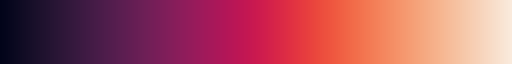

In [9]:
cmap = sns.color_palette("rocket", as_cmap=True)
cmap

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_13879/2690018502.py:18: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('N$_\mathrm{QSO}$')
/tmp/ipykernel_13879/2690018502.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax3.set_xlabel('N$_\mathrm{QSO}$')


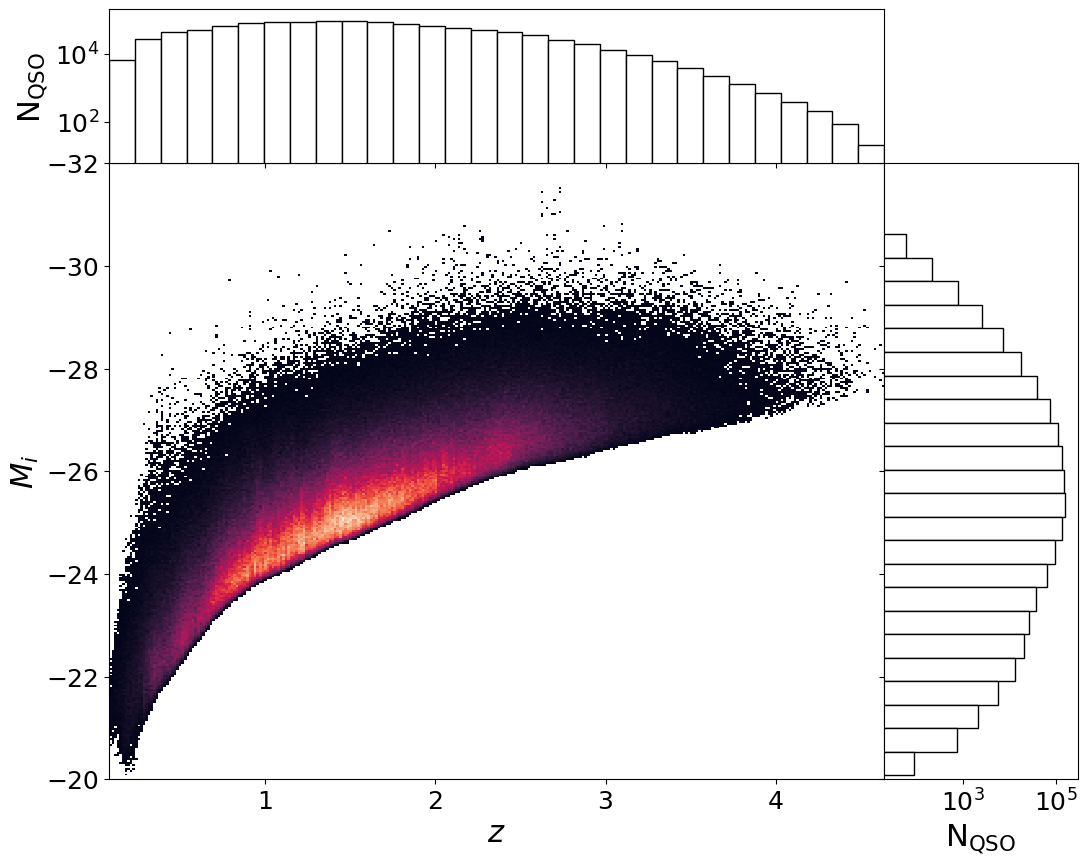

In [10]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = 'black', bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = 'black', orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Compute clustering in four z bins
## $\xi(s)$

In [11]:
# Create the bins array
# rmin = 30 #0.1
# rmax = 80 #180.0
# nbins = 20 # 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'linear'
# rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202

# Create the bins array
offset = 2.5
delta_max = 40
delta_min = np.min((np.floor((30-0.15)/offset), delta_max))

rmin = 30-delta_min*offset # 0.1 # start higher # 1.4 # 30
rmax = 80+delta_max*offset # 200
nbins = 20 + int(delta_min+delta_max) #90 #20
rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
rbins, quaia.recenter(rbins), np.diff(quaia.recenter(rbins))

(array([  2.5,   5. ,   7.5,  10. ,  12.5,  15. ,  17.5,  20. ,  22.5,
         25. ,  27.5,  30. ,  32.5,  35. ,  37.5,  40. ,  42.5,  45. ,
         47.5,  50. ,  52.5,  55. ,  57.5,  60. ,  62.5,  65. ,  67.5,
         70. ,  72.5,  75. ,  77.5,  80. ,  82.5,  85. ,  87.5,  90. ,
         92.5,  95. ,  97.5, 100. , 102.5, 105. , 107.5, 110. , 112.5,
        115. , 117.5, 120. , 122.5, 125. , 127.5, 130. , 132.5, 135. ,
        137.5, 140. , 142.5, 145. , 147.5, 150. , 152.5, 155. , 157.5,
        160. , 162.5, 165. , 167.5, 170. , 172.5, 175. , 177.5, 180. ]),
 array([  3.75,   6.25,   8.75,  11.25,  13.75,  16.25,  18.75,  21.25,
         23.75,  26.25,  28.75,  31.25,  33.75,  36.25,  38.75,  41.25,
         43.75,  46.25,  48.75,  51.25,  53.75,  56.25,  58.75,  61.25,
         63.75,  66.25,  68.75,  71.25,  73.75,  76.25,  78.75,  81.25,
         83.75,  86.25,  88.75,  91.25,  93.75,  96.25,  98.75, 101.25,
        103.75, 106.25, 108.75, 111.25, 113.75, 116.25, 118.75, 121.25

In [12]:
zbin_array = [0.0,1.0,2.0,3.0,4.6]
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(zbin_array)-1))

In [13]:
# h = 0.674
# Omega_m_planck20 = 0.315

In [14]:
cosmo_planck18 = ccl.Cosmology(Omega_c=0.265, Omega_b=Planck18.Ob0, h=Planck18.h, Neff = Planck18.Neff, T_CMB = Planck18.Tcmb0.value, m_nu = Planck18.m_nu, sigma8=0.8, n_s=0.95)

In [15]:
# Om0 = {'Planck': cosmo_planck18['Omega_m'], 'Quaia': 0.343}

## Pick cosmology

In [16]:
cosmo = 'Planck' #'Planck'

<>:40: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_13879/2384192990.py:40: SyntaxWarning: invalid escape sequence '\l'
  ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(zbin_array[i], zbin_array[i+1]),
/tmp/ipykernel_13879/2384192990.py:49: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('$N_\mathrm{QSO}$')


Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0: 0.31              223881 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0: 0.28              464213 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0: 0.25              213734 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Pixels masked by MC but not already by selfunc: 350
G20.5_zmin3.0zmax4.6: 0.22              28436 vs 36458


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


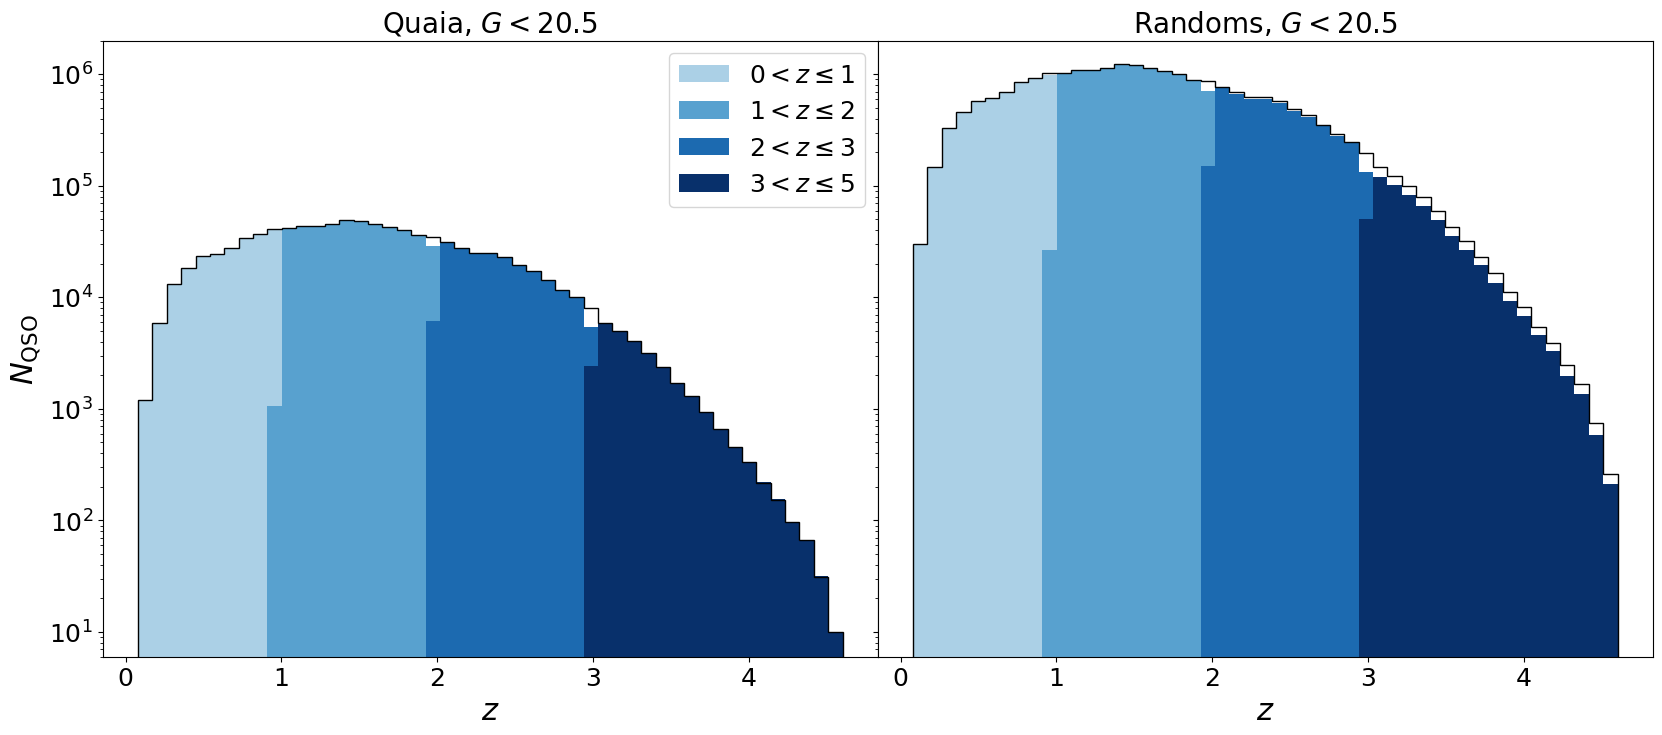

In [17]:
# plot data
bins = np.linspace(0.08, 4.6)
cf = []
fac_rand = 25
mask = 0.5
fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_hi)
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

fn_datahi = '../data/quaia_G{}.fits'.format(G_hi)
tab_datahi = Table.read(fn_datahi)
pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
mask_datahi = selfunc_hi[pixel_indices_datahi]>=np.percentile(selfunc_hi, mask*100)

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

ax1 = fig.add_subplot(gs[0])
ax1.hist(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, histtype = 'step', color='black')

# plot randoms  
ax2 = fig.add_subplot(gs[1])

# for comparison purposes
fn_randhi = '../data/randoms/random_G{}_{}x.fits'.format(G_hi, fac_rand)
tab_randhi = Table.read(fn_randhi)
pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
mask_randhi = selfunc_hi[pixel_indices_randhi]>=np.percentile(selfunc_hi, mask*100)
N_randhi_mask = len(tab_randhi['ra'][mask_randhi])
N_datahi_mask = len(tab_datahi['ra'][mask_datahi])
quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
ax2.hist(tab_randhi['redshift_quaia_'+mask_type], histtype = 'step', bins = bins, 
         color = 'black')


for i in range(len(zbin_array)-1):
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _= quaia.make_bins(G_hi, i, True, 'z', bins = zbin_array, 
                                                                                       tab_gcat_type = 'data', method = 'minmax', 
                                                                                    fac_rand = fac_rand, mask = mask*100, percentile = True)
    ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(zbin_array[i], zbin_array[i+1]), 
             bins = bins, color = cmap_blue[i])
    ax2.hist(tab_randhi_mask_zbin0['redshift_quaia_{}'.format(key_zbin0)], label = 'bin{}'.format(i),
             bins = bins, color = cmap_blue[i])

    cf.append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins, Om0 = Planck18.Om0, #Om0[cosmo], 
                                                      h = Planck18.h)) # h = h, Om0 = Omega_m_planck20))

ax1.set_xlabel('$z$')
ax1.set_ylabel('$N_\mathrm{QSO}$')
ax1.set_yscale('log')
ax1.set_ylim(6,2e6)
ax1.set_title('Quaia, $G<{}$'.format(G_hi))
ax1.legend()

ax2.set_xlabel('$z$')
ax2.set_yscale('log')
ax2.set_ylim(6,2e6)
ax2.set_title('Randoms, $G<{}$'.format(G_hi))
ax2.set_yticklabels([])
plt.show()

# Use delete-one jackknife resampling
## Split the sky into RA stripes

In [18]:
N = 85 #25 #10
ra_bins = np.linspace(0, 360, N+1)
# N = len(ra_bins)
for i in range(N): #-1):
    
    delete = (tab_datahi_mask_zbin0['ra']>=ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] <ra_bins[i])
    print(np.unique(np.digitize(tab_datahi_mask_zbin0['ra'][delete], ra_bins)))

[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 77 78 79 80 81 82 83 84 85]
[ 1  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 77 78 79 80 81 82 83 84 85]
[ 1  2  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 77 78 79 80 81 82 83 84 85]
[ 1  2  3  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 

## Compute $\xi(s)$ in each jackknife bin

In [19]:
cf_jackknife = {zbin: [] for zbin in zbin_array[:-1]}
for j in range(len(zbin_array)-1):
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _= quaia.make_bins(G_hi, j, True, 'z', bins = zbin_array, 
                                                                                       tab_gcat_type = 'data', method = 'minmax', 
                                                                                    fac_rand = fac_rand, mask = mask*100, percentile = True)

    for i in trange(N): #len(ra_bins)-1):
    
        jackknife_data = (tab_datahi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] < ra_bins[i])
        jackknife_rand = (tab_randhi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_randhi_mask_zbin0['ra'] < ra_bins[i])

        cf_jackknife[zbin_array[j]].append(quaia.xi_s(tab_datahi_mask_zbin0[jackknife_data], tab_randhi_mask_zbin0[jackknife_rand], key_zbin0, 
                                             nthreads = nthreads, rbins = rbins, Om0 = Planck18.Om0, #Om0[cosmo], 
                                                      h = Planck18.h)) # h = h, Om0 = Omega_m_planck20))

Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0: 0.31              223881 vs 324336


  0%|          | 0/85 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 85/85 [1:11:28<00:00, 50.46s/it]


Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0: 0.28              464213 vs 648196


  0%|          | 0/85 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 85/85 [2:24:47<00:00, 102.21s/it]  


Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0: 0.25              213734 vs 286508


  0%|          | 0/85 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 85/85 [41:31<00:00, 29.31s/it]


Pixels masked by MC but not already by selfunc: 350
G20.5_zmin3.0zmax4.6: 0.22              28436 vs 36458


  0%|          | 0/85 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 85/85 [03:40<00:00,  2.60s/it]


## Compute the jackknife covariance matrix
### \begin{array}{r}
C_{i j}=\frac{N-1}{N} \sum_{k=1}^N\left[\xi^{(k)}\left(s_{i}\right)-\bar{\xi}\left(s_{i}\right)\right] \\
{\left[\xi^{(k)}\left(s_{j}\right)-\bar{\xi}\left(s_{j}\right)\right]}
\end{array}

In [20]:
C = {zbin: [] for zbin in zbin_array[:-1]}
for zbin in zbin_array[:-1]:
    
    cf_mean = np.nanmean(cf_jackknife[zbin], axis = 0)  # is it ok to ignore nan values?
    delta = cf_jackknife[zbin]-cf_mean
    C[zbin] = (N-1)/N*(delta.T @ delta)

## Retry on scales $10\geq s \geq 85h^{-1}$ Mpc

In [ ]:
# Create the bins array
rmin = 10 # 0.1 # start higher # 1.4 # 30
rmax = 85 # 200
nbins = 20 #90 #20
rbins_chi2 = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'
quaia.recenter(rbins_chi2)

In [ ]:
# plot data
cf = []

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

ax1 = fig.add_subplot(gs[0])
ax1.hist(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, histtype = 'step', color='black')

# plot randoms  
ax2 = fig.add_subplot(gs[1])

# for comparison purposes
ax2.hist(tab_randhi['redshift_quaia_'+mask_type], histtype = 'step', bins = bins, 
         color = 'black')

for zbin in zbin_array[:-1]:
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, int(zbin),True, 'z', bins = zbin_array, 
                                                                                       tab_gcat_type = 'data', method = 'minmax', 
                                                                                    fac_rand = fac_rand, mask = mask*100, percentile = True)
    ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
             bins = bins, color = cmap_blue[int(zbin)])
    ax2.hist(tab_randhi_mask_zbin0['redshift_quaia_{}'.format(key_zbin0)], label = 'bin{}'.format(zbin),
             bins = bins, color = cmap_blue[int(zbin)])

    cf.append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins_chi2))

ax1.set_xlabel('$z$')
ax1.set_ylabel('$N_\mathrm{QSO}$')
ax1.set_yscale('log')
ax1.set_ylim(6,2e6)
ax1.set_title('Quaia, $G<{}$'.format(G_hi))
ax1.legend()

ax2.set_xlabel('$z$')
ax2.set_yscale('log')
ax2.set_ylim(6,2e6)
ax2.set_title('Randoms, $G<{}$'.format(G_hi))
ax2.set_yticklabels([])
plt.show()

In [ ]:
cf_jackknife = {zbin: [] for zbin in zbin_array[:-1]}
for zbin in zbin_array[:-1]:
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, int(zbin),True, 'z', bins = zbin_array, 
                                                                                       tab_gcat_type = 'data', method = 'minmax', 
                                                                                    fac_rand = fac_rand, mask = mask*100, percentile = True)

    for i in range(len(ra_bins)-1):
    
        jackknife_data = (tab_datahi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] < ra_bins[i])
        jackknife_rand = (tab_randhi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_randhi_mask_zbin0['ra'] < ra_bins[i])

        cf_jackknife[zbin].append(quaia.xi_s(tab_datahi_mask_zbin0[jackknife_data], tab_randhi_mask_zbin0[jackknife_rand], key_zbin0, 
                                             nthreads = nthreads, rbins = rbins_chi2))

In [ ]:
C = {zbin: [] for zbin in zbin_array[:-1]}
for zbin in zbin_array[:-1]:
    
    cf_mean = np.nanmean(cf_jackknife[zbin], axis = 0)  # is it ok to ignore nan values?
    delta = cf_jackknife[zbin]-cf_mean
    C[zbin] = (N-1)/N*(delta.T @ delta)

## Save the diagonal elements
### $\sigma_{\xi}\left(s_{i}\right)=\sqrt{C_{i i}}$

In [18]:
for zbin in zbin_array[:-1]:
    
    np.save('../results/sigma_xi_G{}_rmin{}_rmax{}_nbins{}_z{}'.format(G_hi, rmin, rmax, nbins, zbin), np.sqrt(np.diag(C[zbin])))

## Save the full covariance matrix

In [21]:
for i in range(len(zbin_array)-1):
    
    np.save('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_N{}_{}_MC'.format(G_hi, rmin, rmax, nbins, zbin_array[i], zbin_array[i+1], N, cosmo), C[zbin_array[i]])

# Plot

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_13879/3568492025.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.errorbar(r, cf[i], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin_array[i], zbin_array[i+1]),


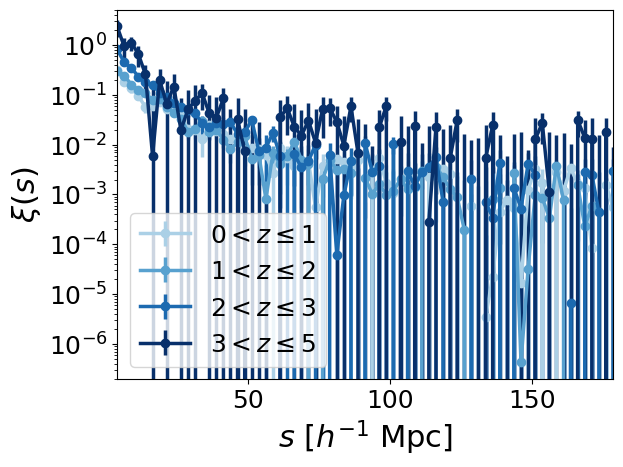

In [22]:
# plot!
r = quaia.recenter(rbins) #_chi2)
for i in range(len(zbin_array)-1):
    sigma = np.sqrt(np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_N{}_{}_MC.npy'.format(G_hi, rmin, rmax, nbins, zbin_array[i], zbin_array[i+1], N, cosmo))))
    plt.errorbar(r, cf[i], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin_array[i], zbin_array[i+1]), 
             linewidth = 2.5, color = cmap_blue[i], yerr = sigma) #np.sqrt(np.diag(C[zbin])))
    plt.xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        plt.xscale('log')
    plt.yscale('log')
    plt.xlim(r[0], r[-1])
    # plt.ylim(4e-3, 5e1)
    plt.legend()
    plt.ylabel(r"$\xi(s)$")
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_13879/3111546966.py:10: SyntaxWarning: invalid escape sequence '\l'
  ax1.errorbar(r, cf[i], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin_array[i], zbin_array[i+1]),
/tmp/ipykernel_13879/3111546966.py:13: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]))


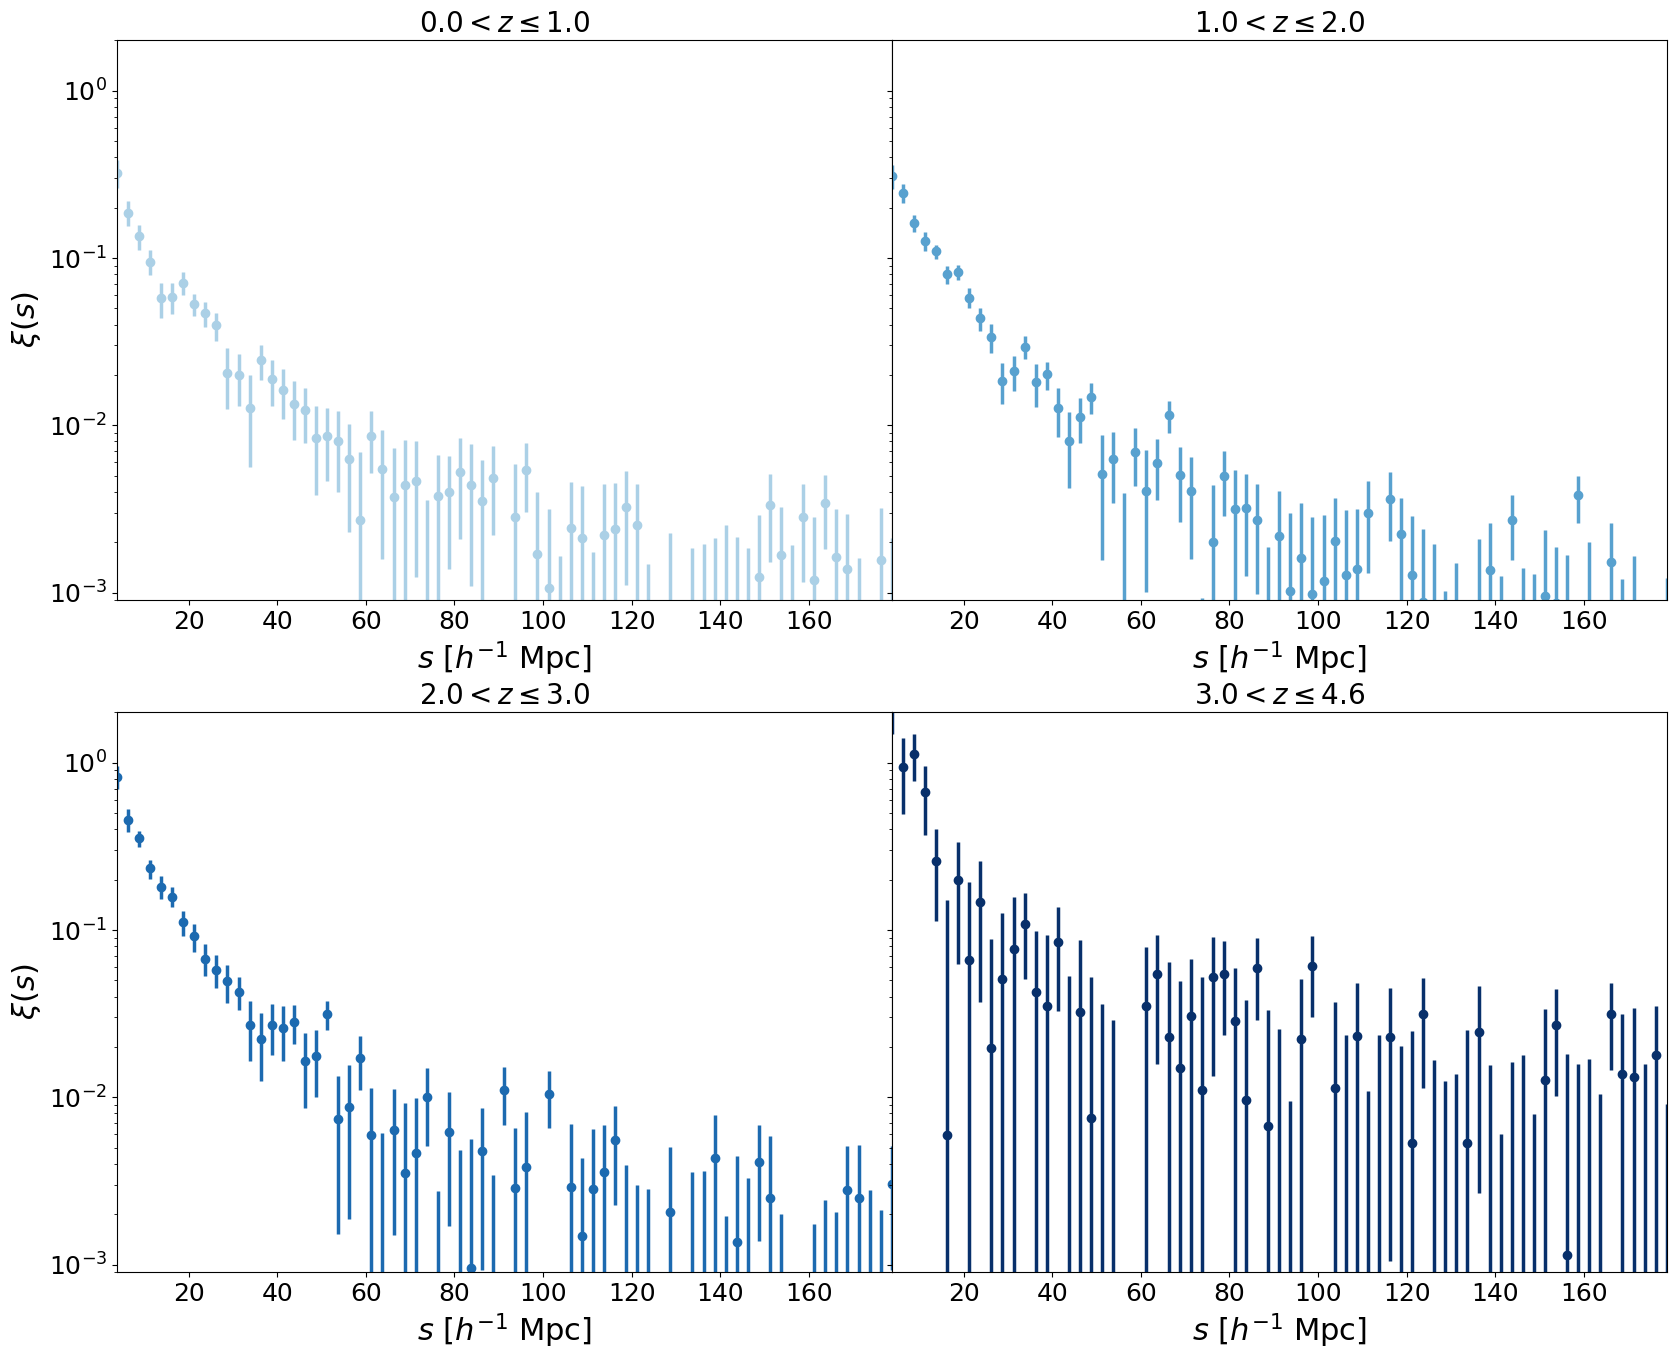

In [23]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.2)

for i in range(len(zbin_array)-1):
    
    ax1 = fig.add_subplot(gs[i])
    
    sigma = np.sqrt(np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_N{}_{}_MC.npy'.format(G_hi, rmin, rmax, nbins, zbin_array[i], zbin_array[i+1], N, cosmo))))    
    ax1.errorbar(r, cf[i], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin_array[i], zbin_array[i+1]), 
             linewidth = 2.5, color = cmap_blue[i], yerr = sigma, linestyle = 'None')
        
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]))
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(r[0], r[-1])
    ax1.set_ylim(9e-4, 2)
    # if zbin>1:
    ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    # else:
    #     ax1.set_xticklabels([])
    if i%2==0:
        ax1.set_ylabel(r"$\xi(s)$")
    else:
        ax1.set_yticklabels([])
    # ax1.legend()

plt.show()

## Plot correlation matrix

<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_13879/1348535701.py:23: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]))


(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)


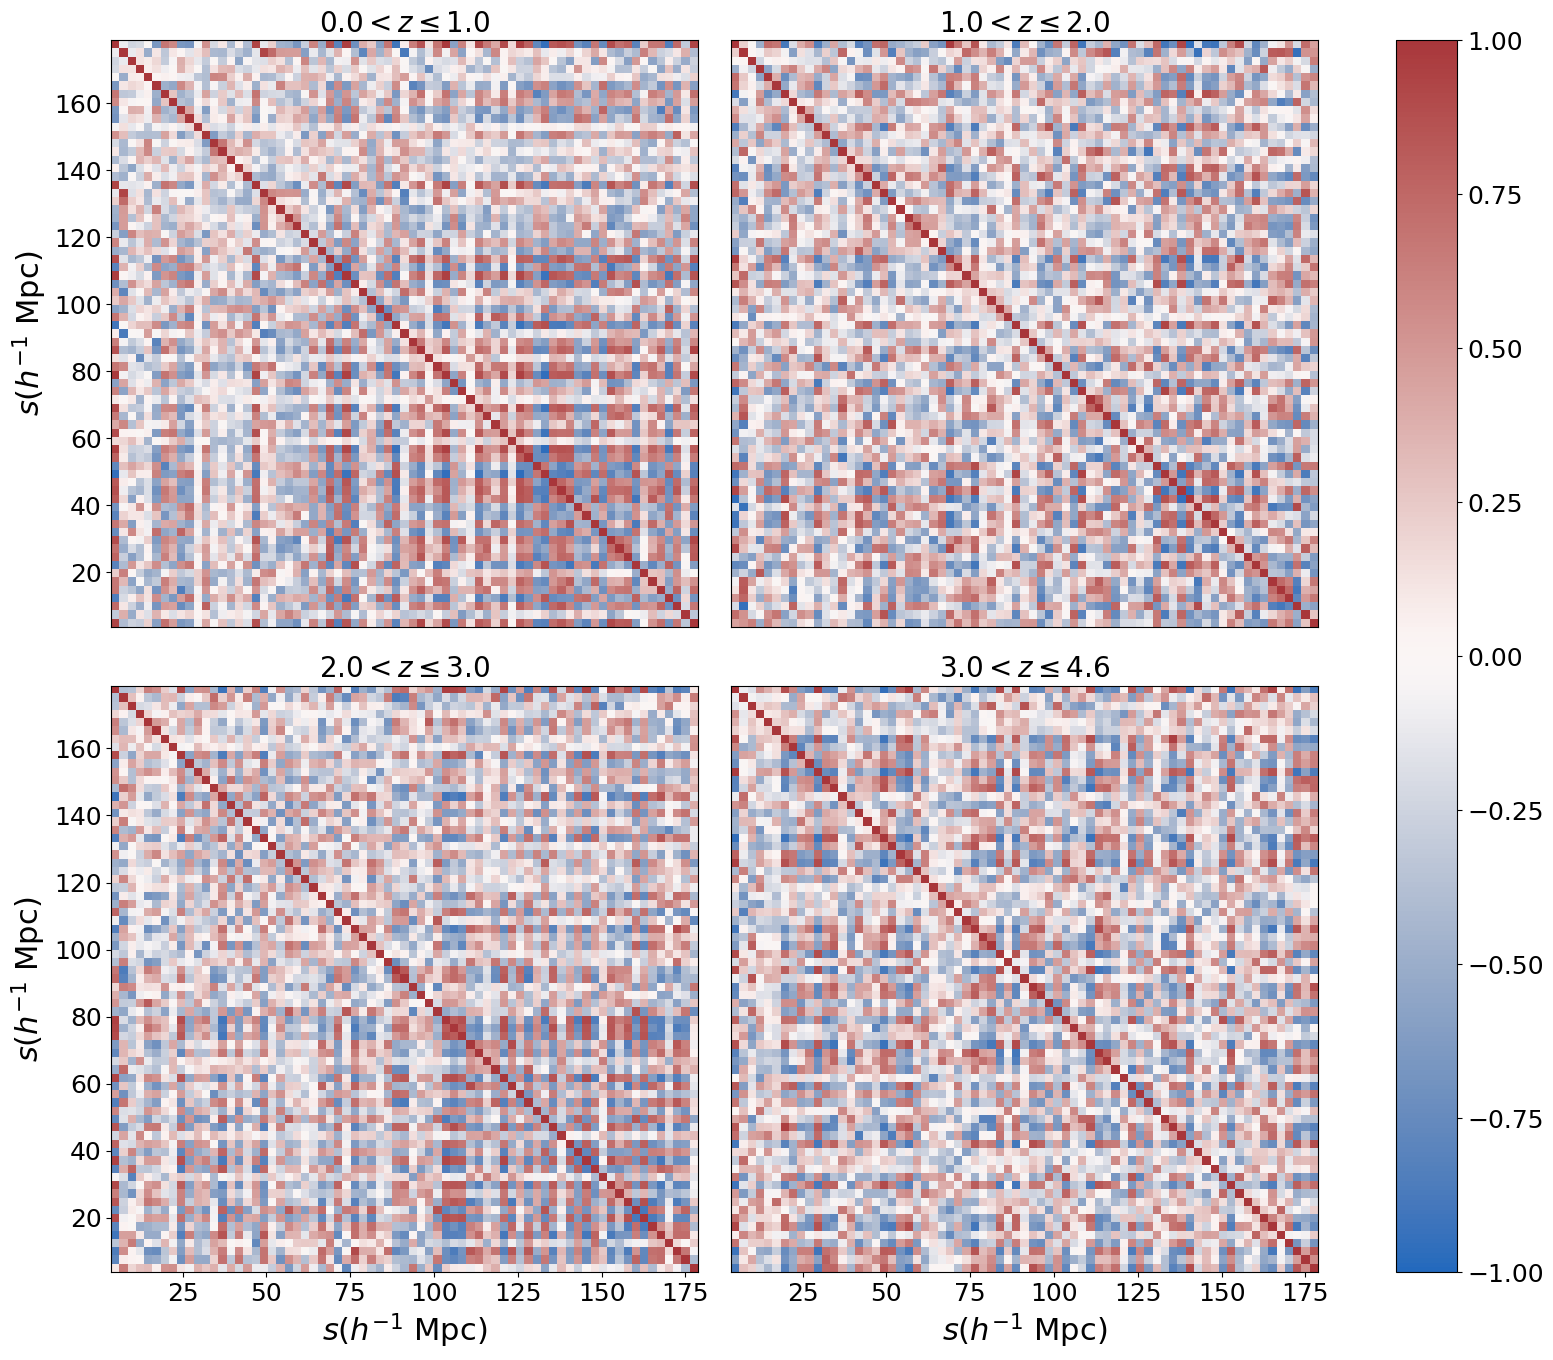

In [24]:
cmap = sns.color_palette("vlag", as_cmap=True)

# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)
axes = []
for i in range(len(zbin_array)-1):
    
    ax1 = fig.add_subplot(gs[i])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_N{}_{}_MC.npy'.format(G_hi, rmin, rmax, nbins, zbin_array[i], zbin_array[i+1], N, cosmo))
    matrix = np.corrcoef(C)
    image = ax1.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
    print(image.get_clim())
    if i>1:
        ax1.set_xlabel('$s (h^{-1}$ Mpc)')
    else:
        ax1.set_xticks([])
    if i %2 == 0:
        ax1.set_ylabel('$s (h^{-1}$ Mpc)')
    else:
        ax1.set_yticks([])
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]))
    axes.append(ax1)
    
fig.colorbar(image, ax = axes)
plt.show()